# 1. Introduction

1.a. 5 examples of the application of ML methods in life:

1. **Recommendation systems**
    Platforms like YouTube, Netflix, Spotify, and online stores use machine learning to suggest videos, music, films, or products based on user preferences.
    Benefit: Users find relevant content faster, and companies improve customer satisfaction and engagement.
        
2) **Email spam filtering**
    Machine learning helps email services detect unwanted messages, such as spam, advertising, or phishing emails.
    Benefit: It saves time, protects users from fraud, and keeps inboxes more organized.

3) **Face recognition on smartphones**
    Many phones use machine learning to recognize the owner’s face and unlock the device securely.
    Benefit: It improves security, makes access faster, and creates a more convenient user experience.

4) **Medical diagnosis support**
    Machine learning helps doctors analyze patient data, scans, or test results to detect diseases.
    Benefit: It can improve diagnostic accuracy, save time, and help identify diseases earlier.

5) **House or apartment price prediction**
    Machine learning can predict the price of housing based on features such as size, location, number of rooms, and condition.
    Benefit: It helps buyers, sellers, and rental platforms estimate fair prices more quickly and accurately.

1.b Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided

* Classification: 2, 4, 5, 6, 8, 10
* Regression: 1, 3, 7
* Clustering: 5
* Association: 5
* Dimensionality reduction: 5, 9

My examples:
* Recommendation systems - Unsupervised learning → clustering
* Email spam detection - Supervised learning → classification
* Face recognition on smartphones - Supervised learning → classification
* Medical diagnosis support - supervised learning → classification
* House or apartment price prediction - Supervised learning → regression.


1.c Think about what the difference is between multiclass and multilabel.

**Multiclass** means that each example belongs to one and only one class out of several possible classes.

Example: a photo of a fruit can be classified as apple, banana, or pear. It cannot be all of them at once.

**Multilabel** means that one example can belong to several classes at the same time.

Example: a movie can have labels comedy, romance, and drama simultaneously.

1.d
Regression, because the needed answer is the price of the house. No, there will be too many classes.

# 2. Introduction to Data Analysis


Imports:

In [5]:
import pandas as pd
import numpy as np
import sklearn
import lightgbm
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [4]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


Loading the data:

In [ ]:
df_train = pd.read_json(f'./data/train.json')

target_column_name = 'price'

In [8]:
df_train.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


The size of the data:

In [51]:
df_train.shape

(49352, 15)

Columns:

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


The target column is 'price'

In [10]:
df_train.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


There are no empty columns.

In [11]:
df_train.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Creating a dataframe with only 3 features: 'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'

In [12]:
train = df_train[['bathrooms', 'bedrooms', 'interest_level', 'price']].reset_index(drop=True)
train.head()

,bathrooms,bedrooms,interest_level,price
0,1.0,1,medium,2400
1,1.0,2,low,3800
2,1.0,2,medium,3495
3,1.5,3,medium,3000
4,1.0,0,low,2795


# 3. Statistical Data Analysis


A histogram to understand the distribution of the target:

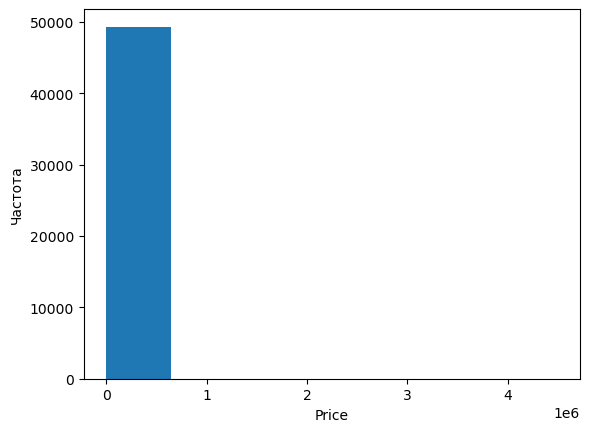

In [18]:
plt.hist(train['price'], bins=7)
plt.xlabel('Price')
plt.ylabel('Частота')
plt.show()

Almost all observations are concentrated in the first bin, at relatively low prices.

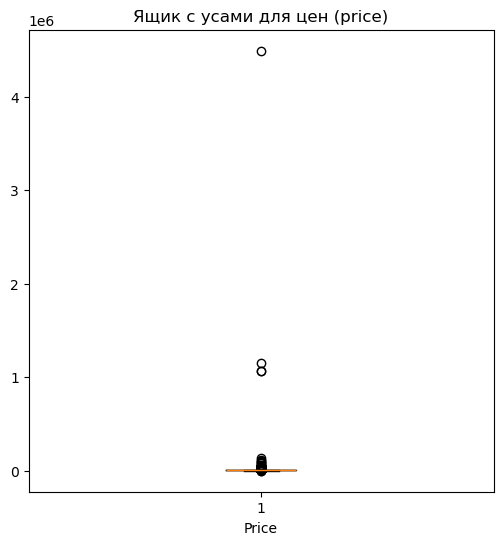

In [25]:
plt.figure(figsize=(6, 6))
plt.boxplot(train['price'])
plt.title('Ящик с усами для цен (price)')
plt.xlabel('Price')
plt.show()

There are some large outliers, we will delete them.

In [26]:
sigms_mask = (train.price >= train.price.quantile(0.01)) & (train.price <= train.price.quantile(0.99))
train = train[sigms_mask]

Let's look at the boxplot now:

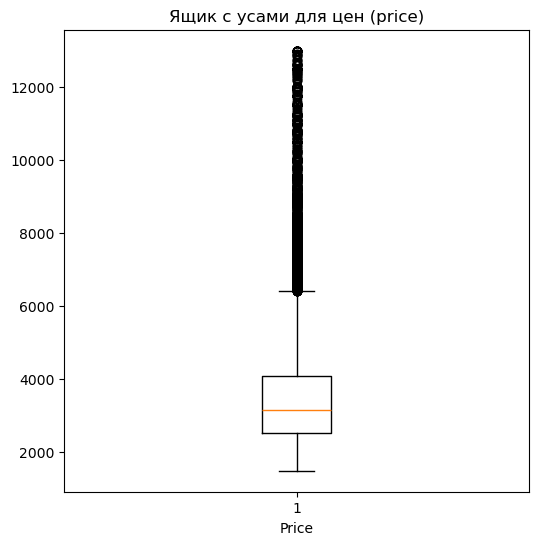

In [27]:
plt.figure(figsize=(6, 6))
plt.boxplot(train['price'])
plt.title('Ящик с усами для цен (price)')
plt.xlabel('Price')
plt.show()

There are still some outliers, but now they are not that high.


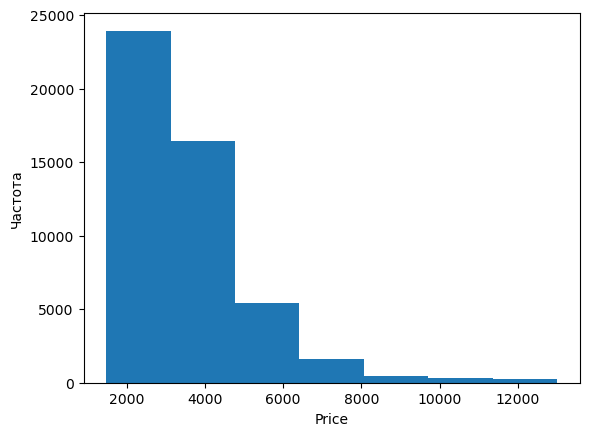

In [28]:
plt.hist(train['price'], bins=7)
plt.xlabel('Price')
plt.ylabel('Частота')
plt.show()

Now the distribution is much better: there are now 10 bins, the distribution is right-skewed

## Characteristics Analysis

### a. What is the type of column 'interest_level'?

In [29]:
train['interest_level'].dtype


dtype('O')

In [30]:
train['interest_level'].drop_duplicates().to_list()

['medium', 'low', 'high']

### b. Print the values in this column. How many entries does each value contain?

In [31]:
train.interest_level.value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

### c. Encode these values. For example, you can replace each value with 0, 1, or 2.

In [32]:
train['interest_level'] = train['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})
train.head()

,bathrooms,bedrooms,interest_level,price
0,1.0,1,1,2400
1,1.0,2,0,3800
2,1.0,2,1,3495
3,1.5,3,1,3000
4,1.0,0,0,2795


### d. Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

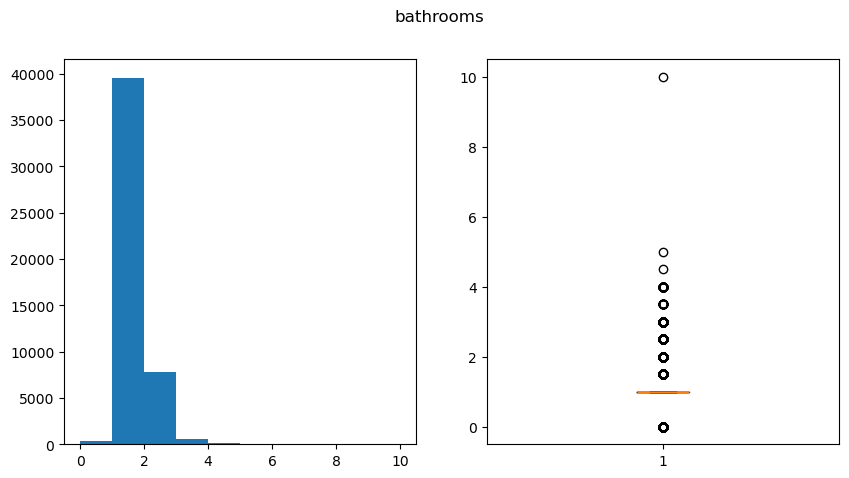

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('bathrooms')
axs[0].hist(train['bathrooms'])
axs[1].boxplot(train['bathrooms'])

plt.show()

There are some outliers, one of them is really high.

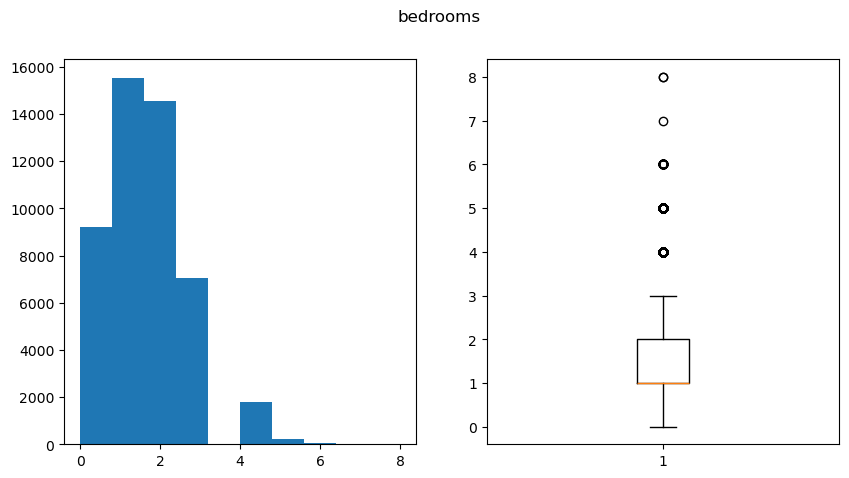

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle('bedrooms')
axs[0].hist(train['bedrooms'])
axs[1].boxplot(train['bedrooms'])

plt.show()

There are fewer outliers here.

## 5. Complex analysis


### a. Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?

In [35]:
corr_matrix = train.corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


<Axes: >

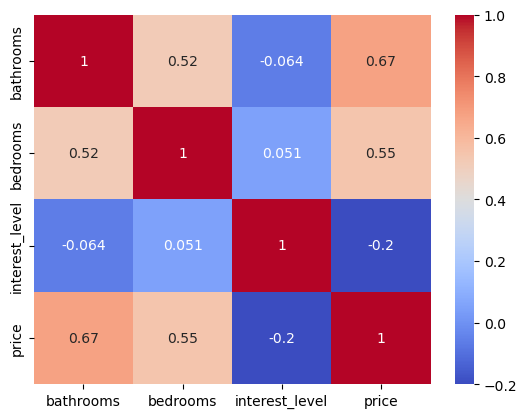

In [36]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

There is a high correlation between bathrooms and bedrooms, bathrooms and price, bedrooms and price.

### b. Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

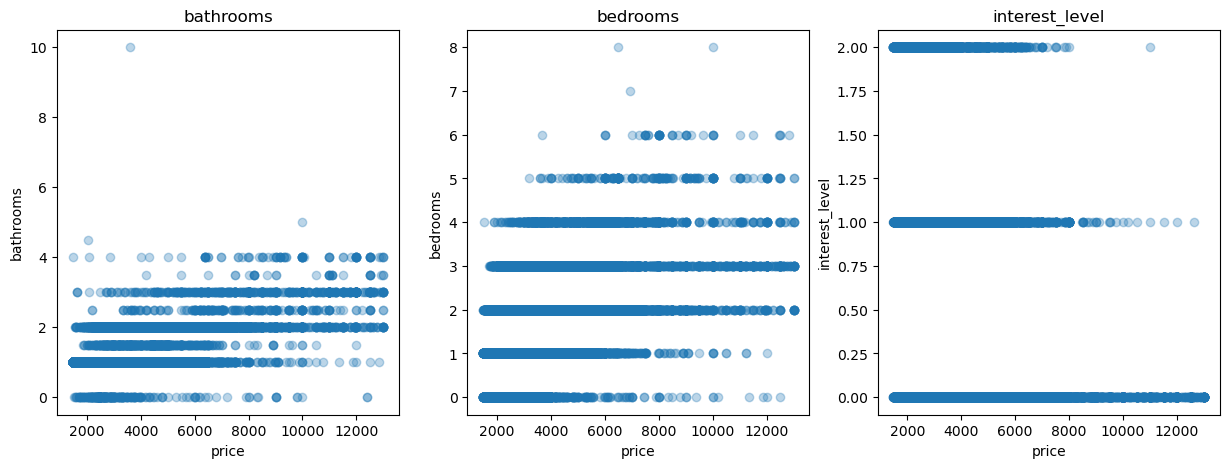

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['bathrooms', 'bedrooms', 'interest_level']):
    axs[i].title.set_text(col)
    axs[i].scatter(train['price'], train[col], alpha=0.3)
    axs[i].set_xlabel('price')
    axs[i].set_ylabel(col)

plt.show()

# 4. Creating Features

New quadratic features:

In [38]:
df_square = train.copy()

df_square['bathrooms_squared'] = df_square['bathrooms']**2
df_square['bedrooms_squared'] = df_square['bedrooms']**2
df_square['interest_level_squared'] = df_square['interest_level']**2

corr_matrix_square = df_square.corr()
corr_matrix_square[['bathrooms', 'bedrooms', 'interest_level', 'price']]

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000
bathrooms_squared,0.956023,0.478817,-0.068558,0.648486
bedrooms_squared,0.548760,0.928277,0.046340,0.543406
interest_level_squared,-0.059410,0.039511,0.944013,-0.182672


<Axes: >

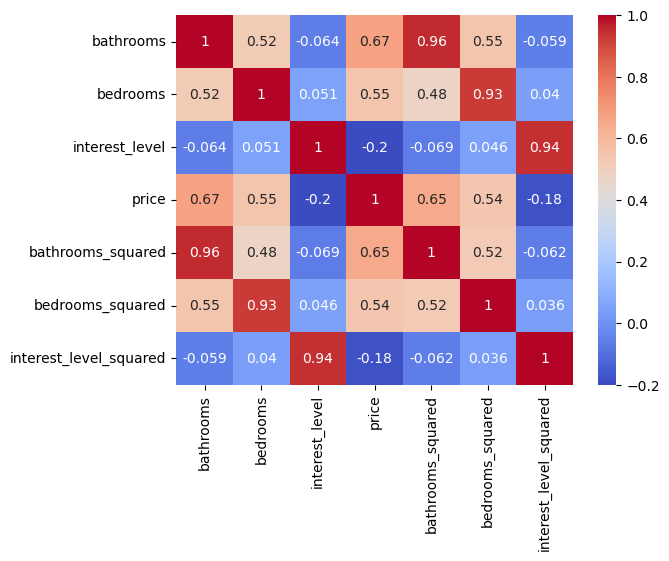

In [40]:
sns.heatmap(corr_matrix_square, annot=True, cmap='coolwarm')

There are some high correlations, but they are not higher than the ones between normal features.

Splitting the data into training and test samples:

In [41]:
df_square = df_square[['bathrooms', 'bedrooms', 'price']]
X = df_square[['bathrooms', 'bedrooms']]
y = df_square['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [52]:
print(f'The size of the dataset: {X.shape}')
print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

The size of the dataset: (48379, 2)
Train size: (38703, 2)
Test size: (9676, 2)


### Initialize PolynomialFeatures() with a degree of 10 and apply PolynomialFeatures() to fit and transform your training and test data.

In [53]:
poly = PolynomialFeatures(degree=10)
poly.fit(X)

X_poly = poly.transform(X)
X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)

print(f'Train size: {X_train_poly.shape}')
print(f'Test size: {X_test_poly.shape}')

Train size: (38703, 66)
Test size: (9676, 66)


# 5. 3 models: linear regression, decision tree and naive model

Creating two empty Pandas DataFrames with columns 'model', 'train', 'test':

In [44]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

## 1) Linear regression

In [45]:
linear_regression = LinearRegression()

linear_regression.fit(X_train_poly, y_train)

y_pred_linear = linear_regression.predict(X_poly)
y_pred_train_linear = linear_regression.predict(X_train_poly)
y_pred_test_linear = linear_regression.predict(X_test_poly)

df_square['linear_pred'] = y_pred_linear 

result_MAE.loc[0] = ['linear_regression', 
    mean_absolute_error(y_train, y_pred_train_linear), 
    mean_absolute_error(y_test, y_pred_test_linear),]

result_RMSE.loc[0] = ['linear_regression', 
    np.sqrt(mean_squared_error(y_train, y_pred_train_linear)), 
    np.sqrt(mean_squared_error(y_test, y_pred_test_linear)),]

## 2) Decision tree

In [46]:
tree = DecisionTreeRegressor(random_state=21)

tree.fit(X_train_poly, y_train)

y_pred_tree = tree.predict(X_poly)
y_pred_train_tree = tree.predict(X_train_poly)
y_pred_test_tree = tree.predict(X_test_poly)

df_square['tree_pred'] = y_pred_tree 

result_MAE.loc[1] = ['decision_tree', 
    mean_absolute_error(y_train, y_pred_train_tree), 
    mean_absolute_error(y_test, y_pred_test_tree),]

result_RMSE.loc[1] = ['decision_tree', 
    np.sqrt(mean_squared_error(y_train, y_pred_train_tree)), 
    np.sqrt(mean_squared_error(y_test, y_pred_test_tree)),]

## 3) Naive models

In [47]:
mean_by_y_train = pd.Series([y_train.mean()] * len(y_train))
mean_by_y_test = pd.Series([y_test.mean()] * len(y_test))

result_MAE.loc[2] = ['naive_mean', 
    mean_absolute_error(y_train, mean_by_y_train), 
    mean_absolute_error(y_test, mean_by_y_test),]

result_RMSE.loc[2] = ['naive_mean', 
    np.sqrt(mean_squared_error(y_train, mean_by_y_train)), 
    np.sqrt(mean_squared_error(y_test, mean_by_y_test)),]

In [48]:
median_by_y_train = pd.Series([y_train.median()] * len(y_train))
median_by_y_test = pd.Series([y_test.median()] * len(y_test))

result_MAE.loc[3] = ['naive_median', 
    mean_absolute_error(y_train, median_by_y_train), 
    mean_absolute_error(y_test, median_by_y_test),]

result_RMSE.loc[3] = ['naive_median', 
    np.sqrt(mean_squared_error(y_train, median_by_y_train)), 
    np.sqrt(mean_squared_error(y_test, median_by_y_test)),]

# 6) Comparing the results

In [49]:
pd.merge(result_MAE.rename(columns={'train': 'MAE train', 'test': 'MAE test'}),
         result_RMSE.rename(columns={'train': 'RMSE train', 'test': 'RMSE test'}), on='model')

,model,MAE train,MAE test,RMSE train,RMSE test
0,linear_regression,756.726511,759.829900,1079.066347,1247.298965
1,decision_tree,756.704419,753.994902,1078.967775,1073.878436
2,naive_mean,1140.445303,1134.133499,1598.460491,1594.366370
3,naive_median,1087.459008,1081.216618,1645.459174,1639.336503


The best model is Decision three with the lowest MAE test (about 753.99) and RMSE test (about 1073.88). The linear regression model also performed well, but its test errors are slightly higher. Both baseline models, naive mean and naive median, gave much worse results.